In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_4.csv
/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_3.csv
/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_2.csv
/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_1.csv
/kaggle/input/unsw-nb15/UNSW_NB15_testing-set.csv
/kaggle/input/unsw-nb15/UNSW-NB15_1.csv
/kaggle/input/unsw-nb15/UNSW_NB15_training-set.csv
/kaggle/input/unsw-nb15/UNSW-NB15_LIST_EVENTS.csv
/kaggle/input/unsw-nb15/UNSW-NB15_4.csv
/kaggle/input/unsw-nb15/UNSW-NB15_3.csv
/kaggle/input/unsw-nb15/UNSW-NB15_2.csv
/kaggle/input/unsw-nb15/NUSW-NB15_features.csv


In [2]:
import tensorflow as tf
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "not available")

2024-04-24 01:11:27.101024: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-24 01:11:27.101244: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-24 01:11:27.313189: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU is not available


In [3]:
import pandas as pd
import numpy as np

import ipaddress

In [4]:
df = pd.concat(
    map(pd.read_csv, 
        ['/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_1.csv',
         '/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_2.csv',
         '/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_3.csv',
         '/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_4.csv']), 
    ignore_index=True)

/tmp/ipykernel_18/2963518926.py:1: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(
/tmp/ipykernel_18/2963518926.py:1: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(
/tmp/ipykernel_18/2963518926.py:1: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(
/tmp/ipykernel_18/2963518926.py:1: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(


In [5]:
df['stime'] = df['stime'].astype('int64') 
df['ltime'] = df['ltime'].astype('int64') 

#taking important features
df = df[['spkts','dpkts','sbytes','dbytes','dur','proto','attack','stime','ltime','sport','dport','saddr','daddr','category']]

df.head()

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,ltime,sport,dport,saddr,daddr,category
0,5,3,650,1330,7.056393,tcp,1,1528088521,1528088528,49960,80,192.168.100.147,192.168.100.7,DoS
1,1,1,60,60,0.000131,arp,1,1528088521,1528088521,-1,-1,192.168.100.7,192.168.100.147,DoS
2,5,3,796,1330,7.047852,tcp,1,1528088521,1528088528,49962,80,192.168.100.147,192.168.100.7,DoS
3,5,3,694,1330,7.047592,tcp,1,1528088521,1528088528,49964,80,192.168.100.147,192.168.100.7,DoS
4,5,3,989,1330,7.046841,tcp,1,1528088521,1528088528,49966,80,192.168.100.147,192.168.100.7,DoS


In [6]:
df['saddr'] =  df['saddr'].apply(lambda x:int(ipaddress.ip_address(x)))
df['daddr'] =  df['daddr'].apply(lambda x:int(ipaddress.ip_address(x)))

df.head()

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,ltime,sport,dport,saddr,daddr,category
0,5,3,650,1330,7.056393,tcp,1,1528088521,1528088528,49960,80,3232261267,3232261127,DoS
1,1,1,60,60,0.000131,arp,1,1528088521,1528088521,-1,-1,3232261127,3232261267,DoS
2,5,3,796,1330,7.047852,tcp,1,1528088521,1528088528,49962,80,3232261267,3232261127,DoS
3,5,3,694,1330,7.047592,tcp,1,1528088521,1528088528,49964,80,3232261267,3232261127,DoS
4,5,3,989,1330,7.046841,tcp,1,1528088521,1528088528,49966,80,3232261267,3232261127,DoS


In [7]:
df['proto'].value_counts()

proto
udp          1996437
tcp          1662812
icmp            9052
arp              213
ipv6-icmp          8
Name: count, dtype: int64

In [8]:
df = df[(df['proto']=='udp') | (df['proto']=='tcp')]

#replacing udp with 0 and tcp with 1
df['proto'] = np.where(df['proto'] == 'udp', 0, 1)

df['category'].value_counts()


#we only need  attack category of dos and ddos type
df = df[(df['category']=='DDoS') | (df['category']=='DoS')]

#resetting index
df.reset_index(drop=True,inplace=True)

df

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,ltime,sport,dport,saddr,daddr,category
0,5,3,650,1330,7.056393,1,1,1528088521,1528088528,49960,80,3232261267,3232261127,DoS
1,5,3,796,1330,7.047852,1,1,1528088521,1528088528,49962,80,3232261267,3232261127,DoS
2,5,3,694,1330,7.047592,1,1,1528088521,1528088528,49964,80,3232261267,3232261127,DoS
3,5,3,989,1330,7.046841,1,1,1528088521,1528088528,49966,80,3232261267,3232261127,DoS
4,5,3,653,1330,7.046596,1,1,1528088521,1528088528,49968,80,3232261267,3232261127,DoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3576765,8,0,480,0,14.869558,0,1,1528099368,1528099383,13250,80,3232261269,3232261123,DDoS
3576766,8,0,480,0,14.869558,0,1,1528099368,1528099383,13251,80,3232261269,3232261123,DDoS
3576767,8,0,480,0,14.869558,0,1,1528099368,1528099383,13252,80,3232261269,3232261123,DDoS
3576768,8,0,480,0,14.869558,0,1,1528099368,1528099383,13253,80,3232261269,3232261123,DDoS


In [9]:
# import os

# # Create the directory if it doesn't exist
# os.makedirs('kaggle/input/datasets', exist_ok=True)

# # Now you can save your CSV files
# df_dos_train.to_csv('kaggle/input/datasets/bot_iot_dos.csv',index=False)
# df_dos_test.to_csv('kaggle/input/datasets/bot_iot_dos.csv',index=False)

In [10]:
#splitting data of category Dos into train and test
df_dos = df[df['category'] == 'DoS']
df_dos_train = df_dos.iloc[:1600000]
df_dos_test = df_dos.iloc[1641197:]

In [11]:
df_dos_train.to_csv("train.csv", index=False)  # Assuming 'index=False' for desired output

df_dos_test.to_csv("test.csv", index=False)  # Assuming 'index=False' for desired output

In [12]:
df_ddos = df[df['category'] == 'DDoS']
df_ddos.reset_index(drop= True,inplace = True)
df_ddos_train = df_ddos.iloc[:1600000]
df_ddos_test = df_ddos.iloc[1917572:]

In [13]:
df_ddos_train.to_csv("ddostrain.csv",index=False)
df_ddos_test.to_csv("ddostest.csv",index=False)

In [14]:
df2 = pd.read_csv("/kaggle/input/unsw-nb15/UNSW-NB15_1.csv")

/tmp/ipykernel_18/2111388369.py:1: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("/kaggle/input/unsw-nb15/UNSW-NB15_1.csv")


In [15]:
df_name = pd.read_csv("/kaggle/input/unsw-nb15/NUSW-NB15_features.csv",sep=",", encoding='cp1252')
columnn_name = df_name['Name']

df2.columns = columnn_name

In [16]:
df2['attack_cat'].fillna('Normal', inplace=True)

/tmp/ipykernel_18/3288052330.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['attack_cat'].fillna('Normal', inplace=True)


In [17]:
df2['attack_cat'].value_counts()

attack_cat
Normal            677785
Generic             7522
Exploits            5409
 Fuzzers            5051
Reconnaissance      1759
DoS                 1167
Backdoors            534
Analysis             526
Shellcode            223
Worms                 24
Name: count, dtype: int64

In [18]:
df2= df2[['Spkts','Dpkts','sbytes','dbytes','dur','proto','Label','Stime','Ltime','sport','dsport','srcip','dstip','attack_cat']]
#replacing the column names with proper name
df2.rename(columns = {'Spkts':'spkts','Dpkts':'dpkts','Label':'attack','Stime':'stime','Ltime':'ltime','sport':'sport','dsport':'dport','srcip':'saddr','dstip':'daddr','attack_cat':'category'}, inplace = True)

In [19]:
df2['saddr'] =  df2['saddr'].apply(lambda x:int(ipaddress.ip_address(x)))
df2['daddr'] =  df2['daddr'].apply(lambda x:int(ipaddress.ip_address(x)))

In [20]:
df2 = df2[(df2['proto']=='udp') | (df2['proto']=='tcp')]

#replacing udp with 0 and tcp with 1
df2['proto'] = np.where(df2['proto'] == 'udp', 0, 1)

In [21]:
# df2 = df2[df2['category']=='Normal']
# df2.reset_index(drop=True,inplace=True)

In [22]:
df2.iloc[:160000].value_counts

<bound method DataFrame.value_counts of Name    spkts  dpkts  sbytes  dbytes       dur  proto  attack       stime  \
0           4      4     528     304  0.036133      0       0  1421927414   
1           2      2     146     178  0.001119      0       0  1421927414   
2           2      2     132     164  0.001209      0       0  1421927414   
3           2      2     146     178  0.001169      0       0  1421927414   
4           4      4     568     312  0.078339      0       0  1421927414   
...       ...    ...     ...     ...       ...    ...     ...         ...   
165126      2      0     264       0  0.000009      0       0  1421933563   
165127     40     42    2542   21006  0.025030      1       0  1421933563   
165128     14     18    1684   10168  1.097950      1       0  1421933562   
165129     12     12    1036    2262  0.004188      1       0  1421933563   
165130     14     14    1140    2366  0.047215      1       0  1421933563   

Name         ltime  sport  dport   

In [23]:
df_train = df2.iloc[:160000]  # Calculate value counts
df_train.to_csv('testunsw_normal.csv', index=False)  # Save value counts to a CSV file

In [24]:
# df_train = df2.iloc[:160000].value_counts
# df_train.to_csv('testunsw_normal.csv',index=False)

In [25]:
df_test = df2.iloc[663637:]
df_test.to_csv('trainunsw_normal.csv',index=False)

In [26]:
df_unsw_normal = pd.read_csv('/kaggle/working/testunsw_normal.csv')
df_bot_dos = pd.read_csv('/kaggle/working/train.csv')
df_bot_ddos = pd.read_csv('/kaggle/working/ddostrain.csv')

In [27]:
df_unsw_normal

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,ltime,sport,dport,saddr,daddr,category
0,4,4,528,304,0.036133,0,0,1421927414,1421927414,33661,1024,1000734720,2511044105,Normal
1,2,2,146,178,0.001119,0,0,1421927414,1421927414,1464,53,1000734726,2511044103,Normal
2,2,2,132,164,0.001209,0,0,1421927414,1421927414,3593,53,1000734725,2511044101,Normal
3,2,2,146,178,0.001169,0,0,1421927414,1421927414,49664,53,1000734723,2511044096,Normal
4,4,4,568,312,0.078339,0,0,1421927414,1421927414,32119,111,1000734720,2511044105,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,2,0,264,0,0.000009,0,0,1421933563,1421933563,47439,53,2511044114,2939006977,Normal
159996,40,42,2542,21006,0.025030,1,0,1421933563,1421933563,35913,14083,1000734726,2511044101,Normal
159997,14,18,1684,10168,1.097950,1,0,1421933562,1421933563,48169,80,1000734726,2511044101,Normal
159998,12,12,1036,2262,0.004188,1,0,1421933563,1421933563,20884,5190,1000734723,2511044102,Normal


In [28]:
df2['category'].value_counts()

category
Normal            671638
Generic             7498
Exploits            4363
 Fuzzers            4061
Reconnaissance      1733
DoS                  571
Shellcode            223
Analysis              58
Backdoors             46
Worms                 24
Name: count, dtype: int64

In [29]:
def data_chunks_creater(df_unsw_normal, df_bot_dos, df_bot_ddos):
    dataframe_list=[]
    # we are taking 10 chunks only but you can take maximum upto 20
    number_of_chunks = 10
    data_limit = 2*80000*number_of_chunks

    # chunk_start and chunk_end are used to partition chunks from the oversampled data
    chunk_start = 0
    chunk_end = 2*80000

    # iterating so the chunks could be merged
    for _ in range(number_of_chunks):

        df_unsw_normal = df_unsw_normal

        df_bot_dos = pd.read_csv('/kaggle/working/train.csv')
        df_bot_dos = df_bot_dos.iloc[:data_limit]
        df_bot_dos = df_bot_dos.iloc[chunk_start:chunk_end]

        df_bot_ddos = pd.read_csv('/kaggle/working/ddostrain.csv')
        df_bot_ddos = df_bot_ddos.iloc[:data_limit]
        df_bot_ddos = df_bot_ddos.iloc[chunk_start:chunk_end]

        # merging the data and also shuffling the data and appending the different chunks in a list, this also ensures the
        # the data is still into chunks its well balanced and consistent
        df = pd.concat([df_unsw_normal, df_bot_dos, df_bot_ddos],
                       ignore_index=True, sort=False)
        df = shuffle(df)
        df.reset_index(drop=True, inplace=True)
        dataframe_list.append(df)

        # updating chunk_start and chunk_end value
        chunk_start = chunk_end
        chunk_end = chunk_end+80000*2

    return dataframe_list

In [30]:
from sklearn.utils import shuffle

In [31]:
data = data_chunks_creater(df_unsw_normal,df_bot_dos,df_bot_ddos)

class_names = ['DoS','Normal','DDoS']

In [32]:
data

[        spkts  dpkts  sbytes  dbytes        dur  proto  attack       stime  \
 0           4      4     568     320   0.004822      0       0  1421930385   
 1          72     74    4238   63516   0.082813      1       0  1421929052   
 2           2      0     308       0   9.887223      1       1  1528095724   
 3           4      4     504     304   0.001774      0       0  1421932219   
 4           5      1     770      60  31.294060      1       1  1528081322   
 ...       ...    ...     ...     ...        ...    ...     ...         ...   
 479995      3      0     462       0  14.707890      1       1  1528095722   
 479996      4      4     568     312   0.323300      0       0  1421931564   
 479997      5      0     770       0  32.033615      1       1  1528081322   
 479998      4      2     428     120  23.344563      1       1  1528081322   
 479999      4      0     616       0  27.037085      1       1  1528081326   
 
              ltime  sport  dport       saddr     

In [33]:
# driv

In [34]:
# driv

In [35]:
# def data_preprocessing(data):
#     x_label_data = list()
#     y_label_data = list()
#     for subset_data in data:
#         df = subset_data
#         x = df.loc[:, df.columns != 'category']
#         # min_max
#         x = (x-x.min())/(x.max()-x.min())
#         df.category = pd.factorize(df.category)[0]
#         y = df['category']
#         x_label_data.append(x)
#         y_label_data.append(y)
#     return x_label_data, y_label_data

In [36]:
# x_label_data,y_label_data = data_preprocessing(data)

# #Model Architecture

In [37]:
import tensorflow as tf

In [38]:
data = np.array(data).reshape(-1, 14)  # Reshape to flatten the extra dimension

driv = pd.DataFrame(data, columns=[
    "spkts", "dpkts", "sbytes", "dbytes", "dur", "proto", "attack", "stime",
    "daddr", "ltime", "sport", "dport", "saddr", "category"
])

print(driv)

        spkts dpkts sbytes dbytes        dur proto attack       stime  \
0           4     4    568    320   0.004822     0      0  1421930385   
1          72    74   4238  63516   0.082813     1      0  1421929052   
2           2     0    308      0   9.887223     1      1  1528095724   
3           4     4    504    304   0.001774     0      0  1421932219   
4           5     1    770     60   31.29406     1      1  1528081322   
...       ...   ...    ...    ...        ...   ...    ...         ...   
4799995    44    46   2750  27620   0.036728     1      0  1421932791   
4799996     8     0    480      0  24.391266     0      1  1528085017   
4799997     8     0    480      0  14.269682     0      1  1528099352   
4799998    10     0    600      0  12.344159     0      1  1528099338   
4799999    34    36   2230  14994   0.011876     1      0  1421932428   

              daddr  ltime  sport       dport       saddr category  
0        1421930385  10287    111  1000734724  2511044

In [39]:
print(driv['category'].unique())

['Normal' 'DDoS' 'DoS' 'Exploits' 'Reconnaissance' 'Generic' ' Fuzzers'
 'Backdoors' 'Worms' 'Shellcode' 'Analysis']


In [40]:
driv['category'] = driv['category'].str.strip()  # Remove leading/trailing spaces

In [41]:
driv['category'].value_counts()

category
DoS               1604970
DDoS              1600000
Normal            1433100
Generic             68720
Exploits            38460
Fuzzers             36280
Reconnaissance      15310
Shellcode            1950
Analysis              580
Backdoors             400
Worms                 230
Name: count, dtype: int64

In [42]:
majority_class  = ['Normal','Generic','Exploits','Fuzzers','DoS','DDoS','Reconnaissance']
minority_class= ['Analysis','Backdoor','Shellcode','Worms']

# Split the dataset into minority and majority

minority = driv[driv['category'].isin(minority_class)].reset_index(drop=True)
majority = driv[driv['category'].isin(majority_class)].reset_index(drop=True)

In [43]:
majority

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,daddr,ltime,sport,dport,saddr,category
0,4,4,568,320,0.004822,0,0,1421930385,1421930385,10287,111,1000734724,2511044100,Normal
1,72,74,4238,63516,0.082813,1,0,1421929052,1421929052,61117,44659,1000734727,2511044098,Normal
2,2,0,308,0,9.887223,1,1,1528095724,1528095734,35342,80,3232261268,3232261123,DDoS
3,4,4,504,304,0.001774,0,0,1421932219,1421932219,41842,57881,1000734720,2511044096,Normal
4,5,1,770,60,31.29406,1,1,1528081322,1528081353,21330,80,3232261268,3232261126,DoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4796835,44,46,2750,27620,0.036728,1,0,1421932791,1421932791,7927,6144,1000734725,2511044102,Normal
4796836,8,0,480,0,24.391266,0,1,1528085017,1528085041,35196,80,3232261267,3232261127,DoS
4796837,8,0,480,0,14.269682,0,1,1528099352,1528099366,37708,80,3232261270,3232261123,DDoS
4796838,10,0,600,0,12.344159,0,1,1528099338,1528099351,37536,80,3232261268,3232261123,DDoS


In [44]:
# majority.replace([np.inf, -np.inf], np.nan, inplace=True)
# majority.dropna(inplace=True)  # Drop rows with NaN values

In [45]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

In [46]:
minority

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,daddr,ltime,sport,dport,saddr,category
0,10,6,1022,268,0.256677,1,1,1421930579,1421930579,32511,80,2939006979,2511044114,Worms
1,62,372,3006,482406,3.422533,1,1,1421930668,1421930672,54215,80,2939006978,2511044107,Worms
2,2,0,210,0,0.000011,0,1,1421930184,1421930184,47364,7631,2939006976,2511044111,Shellcode
3,10,8,1302,354,1.286678,1,1,1421931378,1421931379,28389,80,2939006976,2511044109,Worms
4,10,6,724,268,0.189041,1,1,1421927487,1421927488,3910,19757,2939006979,2511044106,Shellcode
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755,8,4,796,182,0.56016,1,1,1421931775,1421931776,40339,35788,2939006977,2511044106,Shellcode
2756,48,236,2416,308476,3.99375,1,1,1421927786,1421927790,29092,80,2939006977,2511044111,Worms
2757,10,6,626,268,0.451422,1,1,1421931122,1421931123,37428,8861,2939006977,2511044108,Shellcode
2758,10,6,874,268,0.334594,1,1,1421930563,1421930564,43451,64561,2939006977,2511044109,Shellcode


In [47]:
# minority2 = minority.iloc[:len(minority) // 2]  # Select first half using integer division

# # Print the first half of the DataFrame
# print(minority2)

In [48]:
# minority2['category'].value_counts()

In [49]:
# majority2 = majority.iloc[:len(majority) // 2]  # Select first half using integer division

# # Print the first half of the DataFrame
# print(majority2)

In [50]:
# majority2['category'].value_counts()

In [51]:
from collections import Counter

In [52]:
# from imblearn.under_sampling import EditedNearestNeighbours
# from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# encoder = LabelEncoder()
# minority_encoded = minority2.copy()  # Avoid modifying original DataFrame
# minority_encoded['category'] = encoder.fit_transform(minority2['category'])
# majority_encoded = majority2.copy()
# majority_encoded['category'] = encoder.fit_transform(majority2['category'])

# # One-hot encode features in the majority class (excluding encoded 'category')
# encoder = OneHotEncoder(sparse=False)  # Set sparse=False for dense output
# X_encoded = encoder.fit_transform(majority_encoded.drop('category', axis=1))

# # Use encoded labels from both DataFrames
# y_encoded = minority_encoded['category']
# X_res, y_res = enn.fit_resample(X_encoded, y_encoded)

In [53]:
# columns_to_drop = []
# for column in df.columns:
#     if (df[column] == 4262442).any():
#         columns_to_drop.append(column)

# # Drop the columns where the value "4262442" is found
# df_filtered = df.drop(columns=columns_to_drop)

# # Display the filtered DataFrame
# print(df_filtered)

In [54]:
# easy

In [55]:
# search_values = [4262442]
# # Filter the DataFrame based on the search values
# filtered_df = difficult_idx[difficult_idx.isin(search_values).any(axis=1)]

# # Get the column(s) with the specified values
# result_column = filtered_df.columns[filtered_df.isin(search_values).any()]

# # Print the result column(s)
# print(result_column)

In [56]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors

In [57]:
# easy['category'].value_counts()

In [58]:

enn = NearestNeighbors(n_neighbors=500)
enn.fit(majority.drop(columns=['category']))
difficult_idx = enn.kneighbors(minority.drop(columns=['category']), return_distance=False).flatten()
difficult = driv.loc[difficult_idx]
easy = driv.reset_index(drop=True).drop(difficult_idx)

In [59]:
# difficult.replace([np.inf, -np.inf], np.nan, inplace=True)
# difficult.dropna(inplace=True)

# Now, you can fit the KMeans model
kmeans = KMeans(n_clusters=100)
kmeans.fit(difficult.drop(columns=['category']))

compressed = pd.DataFrame(kmeans.cluster_centers_, columns=difficult.columns[:-1])
compressed['category'] = 'Normal'

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [60]:
difficult_min = difficult[difficult['category'].isin(minority_class)]
difficult_max = difficult[difficult['category'] == 'Normal']
difficult_range = difficult_max - difficult_min
difficult_samples = pd.DataFrame()

In [61]:
difficult_max

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,daddr,ltime,sport,dport,saddr,category
1865676,122,126,7806,16008,0.035007,1,0,1421933294,1421933294,24985,143,1000734724,2511044100,Normal
227122,122,126,7810,14540,0.033983,1,0,1421927514,1421927514,23314,143,1000734722,2511044102,Normal
606681,62,58,5928,8010,0.032872,1,0,1421932227,1421932227,26534,22,1000734722,2511044101,Normal
4209196,352,746,18786,1087900,14.528924,1,0,1421931573,1421931588,8941,80,1000734720,2511044099,Normal
2507604,2,2,130,162,0.001116,0,0,1421930635,1421930635,34014,53,1000734723,2511044097,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2530492,2,0,264,0,0.000003,0,0,1421930760,1421930760,1043,53,2511044114,2939006977,Normal
4084051,2,2,146,178,0.001031,0,0,1421929600,1421929600,13352,53,1000734720,2511044101,Normal
2924755,2,2,146,178,0.001056,0,0,1421929640,1421929640,40303,53,1000734725,2511044101,Normal
2456299,52,54,2934,3740,0.022657,1,0,1421933008,1421933008,29988,21,1000734725,2511044104,Normal


In [62]:
for i in range(10):
  r = pd.DataFrame(columns=difficult_min.columns[:-1])
  random_values = np.random.rand(difficult_min.shape[1]-1)
  r.loc[0] = random_values
  dm = difficult_min.iloc[:,:-1]
  sample = dm.add(r, fill_value=0)
  sample['Label'] = minority_class[np.random.randint(0, len(minority_class))]
  difficult_samples = pd.concat([difficult_samples, sample], ignore_index=True)
     

new_train_set = pd.concat([easy, compressed, difficult_min, difficult_samples])
df3 = new_train_set.sample(frac=1).reset_index(drop=True)
     

df3

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,daddr,ltime,sport,dport,saddr,category,Label
0,2,0,308,0,10.583376,1,1,1528095722,1528095733,13095,80,3232261269,3232261123,DDoS,NaN
1,2,1,214,60,0.17898,1,1,1528081342,1528081342,63580,80,3232261270,3232261123,DoS,NaN
2,8,0,480,0,27.127426,0,1,1528084987,1528085014,40393,80,3232261269,3232261125,DoS,NaN
3,4,2,616,120,21.899599,1,1,1528081330,1528081352,61382,80,3232261268,3232261126,DoS,NaN
4,2,1,214,60,0.174731,1,1,1528081375,1528081376,12052,80,3232261270,3232261123,DoS,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4769955,24,20,2158,1918,0.005644,1,0,1421932503,1421932503,54451,5190,1000734722,2511044096,Normal,NaN
4769956,7,1,984,60,45.673927,1,1,1528095779,1528095825,19523,80,3232261270,3232261123,DDoS,NaN
4769957,15,0,900,0,13.660818,0,1,1528099338,1528099352,18017,80,3232261267,3232261123,DDoS,NaN
4769958,5,0,770,0,15.775597,1,1,1528095747,1528095762,60199,80,3232261269,3232261123,DDoS,NaN


In [63]:
new_train_set['category'].value_counts()

category
DoS               1592293
DDoS              1587313
Normal            1422027
Generic             68169
Exploits            38158
Fuzzers             35979
Reconnaissance      15173
Shellcode            2517
Analysis              656
Backdoors             396
Worms                 269
Name: count, dtype: int64

In [64]:
# merged_df = new_train_set.copy()

# # Merge 'category' and 'Label' columns and fill NaN values in 'Label' with values from 'category'
# merged_df['category2'] = new_train_set['Label'].fillna(new_train_set['category'])

# # Drop the original 'category' and 'Label' columns
# merged_df.drop(['category', 'Label'], axis=1, inplace=True)

# # Display the modified DataFrame
# print(merged_df)

In [65]:
difficult_samples

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,daddr,ltime,sport,dport,saddr,Label
0,0.256785,0.983897,0.854709,0.104844,0.454495,0.164238,0.815481,0.323394,0.403016,0.526106,0.650723,0.837014,0.661017,Backdoor
1,10.0,8.0,804.0,1092.0,0.790775,1.0,1.0,1421932817.0,1421932818.0,54298.0,80.0,2939006976.0,2511044110.0,Backdoor
2,10.0,8.0,804.0,1092.0,0.790775,1.0,1.0,1421932817.0,1421932818.0,54298.0,80.0,2939006976.0,2511044110.0,Backdoor
3,10.0,8.0,804.0,1092.0,0.790775,1.0,1.0,1421932817.0,1421932818.0,54298.0,80.0,2939006976.0,2511044110.0,Backdoor
4,10.0,8.0,804.0,1092.0,0.790775,1.0,1.0,1421932817.0,1421932818.0,54298.0,80.0,2939006976.0,2511044110.0,Backdoor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005,10.0,6.0,1308.0,268.0,0.260798,1.0,1.0,1421929207.0,1421929207.0,26652.0,80.0,2939006976.0,2511044110.0,Backdoor
7006,10.0,6.0,1308.0,268.0,0.260798,1.0,1.0,1421929207.0,1421929207.0,26652.0,80.0,2939006976.0,2511044110.0,Backdoor
7007,10.0,6.0,1308.0,268.0,0.260798,1.0,1.0,1421929207.0,1421929207.0,26652.0,80.0,2939006976.0,2511044110.0,Backdoor
7008,10.0,6.0,1308.0,268.0,0.260798,1.0,1.0,1421929207.0,1421929207.0,26652.0,80.0,2939006976.0,2511044110.0,Backdoor


In [66]:
# value_counts =difficult_samples['Label'].value_counts()
# print(value_counts)

In [67]:
# df3 = df3.drop(columns=['Label'])

In [68]:
# from sklearn.impute import SimpleImputer
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier

# # Assuming 'df3' is your dataframe with NaN values
# # Replace NaN values with the mean of each column for features
# imputer = SimpleImputer(strategy='mean')
# X_imputed = imputer.fit_transform(merged_df.drop('category2', axis=1))

# # Check and handle NaN values in the target variable 'category'
# y_imputed = merged_df['category2'].fillna(merged_df['category2'].mode()[0])  # Example: Replace NaN with the mode

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_imputed, y_imputed, test_size=0.2, random_state=42)

# # Initialize and train the Random Forest Classifier
# clf = RandomForestClassifier()
# clf.fit(X_train, y_train)

# # Evaluate the classifier
# accuracy = clf.score(X_test, y_test)
# print(f"Accuracy: {accuracy}")

In [69]:
# X_test

In [70]:
# from sklearn.metrics import confusion_matrix

# # Assuming 'clf' is your trained Random Forest Classifier
# # Predict on the test set
# y_pred = clf.predict(X_test)

# # Calculate the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Print the confusion matrix
# print("Confusion Matrix:")
# print(cm)

In [71]:
# class_names = ['DDoS'  ,       
# 'DoS'          ,
# 'Normal'        ,   
# 'Shellcode'      ,    
# 'Worms'           , 
# 'Backdoor'         ,  
# 'Analysis' ]  # Add your class names here

# # Calculate the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Create a DataFrame for the confusion matrix with class names as rows and columns
# cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# # Print the confusion matrix
# print("Confusion Matrix:")
# print(cm_df)

In [72]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix

# # Define your class names
# class_names = ['DDoS', 'DoS', 'Normal', 'Shellcode', 'Worms', 'Backdoor', 'Analysis']

# # Assuming 'clf' is your trained Random Forest Classifier
# # Predict on the test set
# y_pred = clf.predict(X_test)

# # Calculate the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Create a DataFrame for the confusion matrix with class names as rows and columns
# cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# # Plot the confusion matrix using Seaborn
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
# plt.title('Confusion Matrix')
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.show()

In [73]:
# unique_labels = le.transform(merged_df['category2'].unique())

In [74]:
df3 = df3.drop('Label', axis=1)

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning

Average Accuracy: 0.9600466097691556
Average Precision: 0.9616835741161557
Average Recall: 0.9600466097691556
Average F1-score: 0.9598873994948682
Average Confusion Matrix:
[[0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 4.790000e+01
  1.770000e+01 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 2.000000e-01 0.000000e+00 0.000000e+00 2.260000e+01
  9.300000e+00 3.000000e-01 0.000000e+00 0.000000e+00 7.200000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 1.537925e+05 4.938800e+03 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 1.024110e+04 1.484989e+05 2.840000e+02
  1.356000e+02 3.630000e+01 0.000000e+00 2.200000e+01 1.140000e+01
  0.000000e+00]
 [0.000000e+00 1.000000e+00 0.000000e+00 2.800000e+00 2.821900e+03
  8.213000e+02 4.150000e+01 0.000000e+00 4.610000e+01 8.120000e+01
  0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 2.200000e+00 5.901000e+02
  2.912900

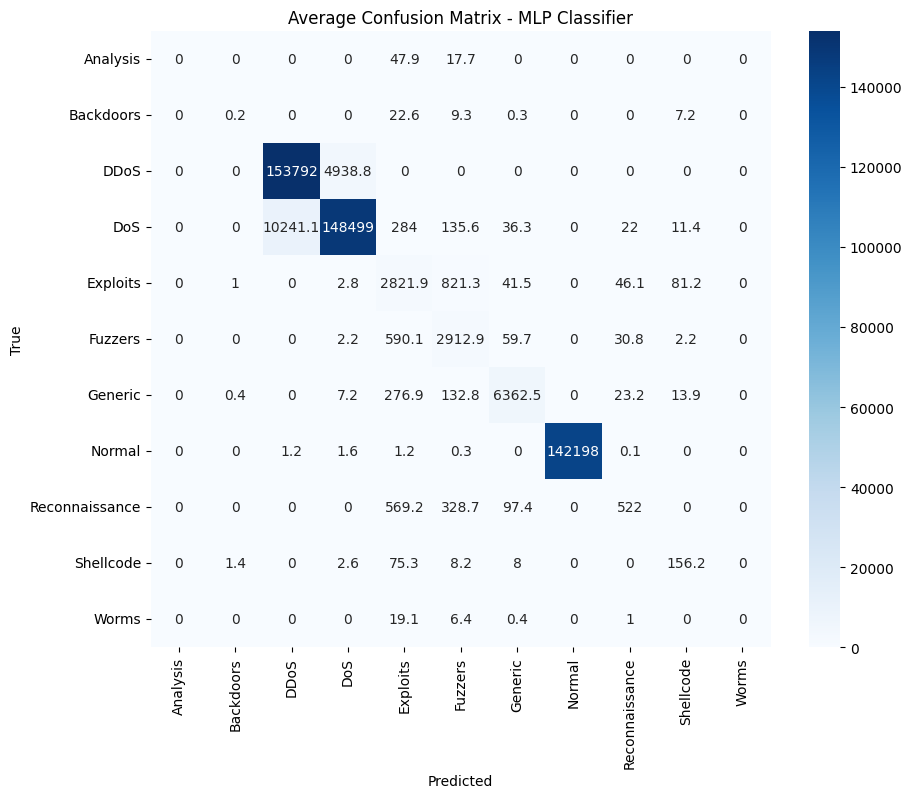

In [75]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df3' is your dataframe with NaN values and 'category' is your target column
# Drop rows with missing values in the 'category' column
df3 = df3.dropna(subset=['category'])

# Separate features (X) and target variable (y)
X = df3.drop('category', axis=1)
y = df3['category']

# Scale the features to ensure non-negativity
scaler = MinMaxScaler()  # Using MinMaxScaler for non-negative scaling
X_scaled = scaler.fit_transform(X)

# Perform PCA for dimensionality reduction
pca = PCA(n_components=5)  # Example: Reduce to 5 principal components
X_pca = pca.fit_transform(X_scaled)

# Label encode the target variable 'category'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Initialize stratified k-fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Initialize lists to store accuracy, precision, recall, and F1-score for each fold
accuracies = []
precisions = []
recalls = []
f1_scores = []
cms = []  # List to store confusion matrices

# Perform stratified k-fold cross-validation
for train_index, test_index in skf.split(X_pca, y_encoded):
    X_train, X_test = X_pca[train_index], X_pca[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Initialize and train the MLP Classifier
    mlp_classifier = MLPClassifier(random_state=42)
    mlp_classifier.fit(X_train, y_train)

    # Predict on the test set
    y_pred = mlp_classifier.predict(X_test)

    # Calculate accuracy, precision, recall, and F1-score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)

    # Append the scores to the lists
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

# Calculate and print the average accuracy, precision, recall, and F1-score
avg_accuracy = sum(accuracies) / len(accuracies)
avg_precision = sum(precisions) / len(precisions)
avg_recall = sum(recalls) / len(recalls)
avg_f1 = sum(f1_scores) / len(f1_scores)
print(f"Average Accuracy: {avg_accuracy}")
print(f"Average Precision: {avg_precision}")
print(f"Average Recall: {avg_recall}")
print(f"Average F1-score: {avg_f1}")

# Calculate and print the average confusion matrix
avg_cm = sum(cms) / len(cms)
print("Average Confusion Matrix:")
print(avg_cm)

# Convert the average confusion matrix to a DataFrame for easier plotting with Seaborn
cm_df = pd.DataFrame(avg_cm, index=label_encoder.classes_, columns=label_encoder.classes_)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Average Confusion Matrix - MLP Classifier')
plt.show()
